# **Analisis Spasial-Temporal: Deteksi Perubahan Tanah Terbuka Wilayah Pulau Menggunakan ENDBSI dan Masking Air AWEI**

---
**oleh : Defani Arman Alfitriansyah**

<div align="left">
  <a href="https://linkedin.com/in/defaniarmanalfitriansyah"><img src="https://img.shields.io/badge/LinkedIn-0077B5?style=flat-square&logo=linkedin&logoColor=white" alt="LinkedIn" /></a>
  <a href="https://medium.com/@defaniarman"><img src="https://img.shields.io/badge/Medium-12100E?style=flat-square&logo=medium&logoColor=white" alt="Medium" /></a>
  <a href="https://tiktok.com/@defaniarman"><img src="https://img.shields.io/badge/TikTok-000000?style=flat-square&logo=tiktok&logoColor=white" alt="TikTok" /></a>
  <a href="https://www.instagram.com/de.fanii"><img src="https://img.shields.io/badge/Instagram-E4405F?style=flat-square&logo=instagram&logoColor=white" alt="Instagram" /></a>
  <a href="https://www.kaggle.com/defani123"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat-square&logo=kaggle&logoColor=white" alt="Kaggle" /></a>
  <a href="https://rpubs.com/defanii"><img src="https://img.shields.io/badge/RPubs-75AADB?style=flat-square&logo=r&logoColor=white" alt="RPubs" /></a>
  <a href="https://www.behance.net/defaniarman"><img src="https://img.shields.io/badge/Behance-1769FF?style=flat-square&logo=behance&logoColor=white" alt="Behance" /></a>
  <a href="mailto:defaniarman@gmail.com"><img src="https://img.shields.io/badge/Email-D14836?style=flat-square&logo=gmail&logoColor=white" alt="Email" /></a>
  <a href="https://github.com/Defani"><img src="https://img.shields.io/badge/GitHub-100000?style=flat-square&logo=github&logoColor=white" alt="GitHub" /></a>
</div>


---



#**Tujuan**
Analisis ini bertujuan untuk memantau dinamika perubahan luas dan tingkat keterbukaan lahan (tanah terbuka/ *bare soil*) di suatu kawasan kepulauan selama periode 2019–2026.

Tantangan utama dalam ekstraksi data *remote sensing* di kawasan pulau adalah memisahkan wilayah daratan dari lautan/badan air serta menghilangkan gangguan bayangan topografi pesisir. Untuk mengatasi hal ini, kita menggunakan pendekatan dua tahap:
1. Menggunakan indeks air ($AWEI_{sh}$) untuk mengisolasi daratan (melakukan masking pada lautan/badan air).
2. Menghitung indeks tanah terbuka ($ENDBSI$) secara eksklusif pada wilayah daratan yang telah lolos validasi masking.





---

## **1. Rumus Indeks *(Indices)***
Berdasarkan saluran spektral (*bands*) pada satelit Sentinel-2 (B2=Blue, B3=Green, B4=Red, B8=NIR, B11=$SWIR_1$, B12=$SWIR_2$), berikut adalah indeks yang digunakan:

>### **A. Automated Water Extraction Index - shadow ($AWEI_{sh}$)**
Indeks ini dirancang khusus untuk mengekstrak badan air secara otomatis sekaligus menghilangkan *noise* dari bayangan gelap. **(Feyisa et al., 2014)**

>$$AWEI_{sh} = Blue + 2.5 \times Green - 1.5 \times (NIR + SWIR_1) - 0.25 \times SWIR_2$$

>### **B. Enhanced Normalized Difference Bare Soil Index ($ENDBSI$)**
Indeks ini sensitif untuk membedakan tanah terbuka murni dari tutupan lahan lain (seperti bangunan beton atau vegetasi kering). **(Chen et al., 2026)**

$$ENDBSI = \frac{3 \times SWIR_1 + Red - Blue - Green - NIR - SWIR_2}{3 \times SWIR_1 + Red + Blue + Green + NIR + SWIR_2}$$

---

## **2. Logika Ambang Batas (*Thresholding & Masking*)**

>Kunci akurasi di wilayah kepulauan adalah proses pemisahan air dan daratan. Indeks $AWEI_{sh}$ diformulasikan agar nilai pantulan air menjadi positif, dan non-air menjadi negatif. Oleh karena itu, nilai **0** digunakan sebagai batas absolut (*threshold*). **(Feyisa et al., 2014)**

>Logika *if-else* (dalam bentuk fungsi piksel spasial) untuk masking didefinisikan sebagai:

$$
\text{Status Piksel}_{(x,y)} =
\begin{cases}
\text{Air (Masked / Dihapus)}, & \text{jika } AWEI_{sh} > 0 \\
\text{Daratan (Valid untuk ENDBSI)}, & \text{jika } AWEI_{sh} \le 0
\end{cases}
$$



---

>Jika $AWEI_{sh} \le 0$, maka piksel tersebut diproses oleh rumus $ENDBSI$. Jika $AWEI_{sh} > 0$, piksel diubah menjadi *NoData* sehingga lautan tidak merusak rata-rata statistik pulau.

---

## **3. Pustaka Pendukung (Python Libraries)**

Alur kerja komputasi ini dieksekusi menggunakan bahasa pemrograman Python. Berikut adalah pustaka utama yang digunakan beserta referensinya:

| Pustaka Python | Fungsi Utama dalam Analisis | Referensi Publikasi |
| :--- | :--- | :--- |
| <a href="https://geemap.org/"><img src="https://geemap.org/assets/logo.png" alt="geemap" height="25" /></a><br><b>`geemap`</b> | Memfasilitasi integrasi dan komputasi interaktif dengan API Google Earth Engine. | Wu (2020) |
| <a href="https://cartoee.readthedocs.io/en/latest/index.html"><img src="https://cartoee.readthedocs.io/en/latest/_static/logo.png" alt="cartoee" height="25" /></a><br><b>`cartoee`</b> | Modul dari geemap untuk menghasilkan tata letak peta statis dengan standar kualitas publikasi jurnal. | Markert (2019) |
| <a href="https://matplotlib.org/"><img src="https://matplotlib.org/_static/logo_dark.svg" alt="matplotlib" height="25" /></a><br><b>`matplotlib`</b> | Pembuatan kerangka dasar plot 2D, grafik tren temporal, dan manajemen elemen warna visualisasi. | Hunter (2007) |
| <a href="https://scitools.org.uk/cartopy/docs/latest/"><img src="https://cartopy.readthedocs.io/stable/_static/cartopy.png" alt="cartopy" height="25" /></a><br><b>`cartopy`</b> | Menangani sistem referensi koordinat (CRS) dan proyeksi kartografi spasial pada tata letak peta. | Met Office (2013) |

# **KODE ANALISIS**


---



## **Install Library**

Tahap ini bertujuan untuk memasang seluruh pustaka (*library*) Python pihak ketiga yang dibutuhkan untuk komputasi spasial, yang biasanya tidak tersedia secara *default* di lingkungan kerja virtual (seperti Google Colab). Perintah ini menggunakan manajer paket `pip` dan cukup dieksekusi satu kali pada awal sesi.

Berikut adalah rincian fungsional dari pustaka yang dipasang:
* **`earthengine-api`**: Pustaka dasar resmi dari Google yang memungkinkan Python mengirimkan instruksi komputasi ke server Earth Engine.
* **`geemap`**: Memfasilitasi integrasi GEE dengan Python, mempermudah pemrosesan koleksi citra, dan menyediakan modul `cartoee` untuk ekspor peta statis.
* **`cartopy`**: Menangani proyeksi kartografi spasial dan sistem referensi koordinat (CRS) agar peta dapat digambar dengan presisi lintang/bujur yang akurat.
* **`matplotlib`**: Mesin utama untuk menggambar (*plotting*) grafik tren temporal 2D, tata letak kanvas, *colorbar*, dan elemen legenda pada peta.
* **`imageio`**: Modul yang bertugas membaca gambar-gambar peta spasial tahunan yang telah diekspor, lalu merangkainya menjadi satu berkas animasi berformat GIF.

In [13]:
!pip install earthengine-api geemap cartopy matplotlib imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.7 MB/s eta 0:00:00


## **Import Library**

Setelah seluruh pustaka terpasang, tahap selanjutnya adalah memanggil modul-modul tersebut ke dalam memori lingkungan kerja (Jupyter Notebook/Google Colab). Modul-modul ini sangat krusial untuk mengeksekusi komputasi spasial, membuat grafik tren, hingga merender animasi akhir.

Berikut adalah fungsi dari masing-masing modul yang dipanggil:

* **`import ee`**: Memanggil modul inti Google Earth Engine untuk mengakses objek spasial (seperti `ee.Image`, `ee.Reducer`, `ee.Geometry`) dan mengirimkan perintah ke server Google.
* **`import geemap.cartoee as cartoee` & `geemap.colormaps as cm`**: Memanggil ekstensi pemetaan untuk membuat tata letak peta statis dengan standar publikasi jurnal, serta menyediakan palet warna saintifik (seperti untuk tanah terbuka).
* **`matplotlib.pyplot` beserta modul turunannya (`mpl`, `mpatches`, `LinearSegmentedColormap`)**: Digunakan untuk membuat kanvas *plot* 2D, memanipulasi rentang gradien warna secara kustom (gabungan warna daratan dan air), serta membuat kotak legenda (*patch*) secara manual.
* **`cartopy.crs` beserta pengatur *Gridliner* (`GeoAxes`, `LONGITUDE_FORMATTER`, dll)**: Modul ini bertanggung jawab atas proyeksi bumi (seperti *PlateCarree*) dan memastikan bahwa garis bantu (*gridlines*) lintang dan bujur ditampilkan dalam format derajat yang tepat dan profesional.
* **`imageio` & `os`**: `imageio` bertugas membaca hasil render bingkai (*frame*) peta tahunan dan merangkainya menjadi satu berkas animasi berformat `.gif`. Sementara itu, `os` digunakan untuk manajemen sistem (menghapus *file* gambar `.png` sementara setelah GIF selesai dibuat agar penyimpanan tidak penuh).

>*(Catatan: Penyesuaian `cartoee.GeoAxes = GeoAxes` di bagian bawah *import* digunakan sebagai perlindungan kompatibilitas / *patch* agar versi terbaru dari `cartopy` dapat berjalan mulus dengan modul `cartoee` tanpa memunculkan eror visual).*

In [26]:
import ee
import geemap.cartoee as cartoee
import geemap.colormaps as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import imageio, os
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.geoaxes import GeoAxes

cartoee.GeoAxes = GeoAxes
cartoee.GeoAxesSubplot = GeoAxes
cartoee.ccrs = ccrs
ee.Authenticate()
ee.Initialize(project='ee-defaniarman')

### **Login GEE**

Tahap ini merupakan gerbang utama untuk menghubungkan lingkungan kerja Python (seperti Jupyter Notebook atau Google Colab) dengan peladen komputasi awan Google Earth Engine (GEE). Proses ini terdiri dari dua langkah fundamental yang wajib dieksekusi sebelum modul spasial lainnya dapat dipanggil:

*   **Autentikasi (`ee.Authenticate()`):** Memicu protokol keamanan untuk memverifikasi identitas dan meminta token akses resmi dari akun Google Anda. Langkah ini memastikan bahwa Anda memiliki izin yang sah untuk menggunakan layanan API Earth Engine. Anda dapat menemukan panduan lebih detail tentang proses autentikasi di dokumentasi `geemap`:
    *   [GEEMAP Authentication in Colab](https://geemap.org/notebooks/00_ee_auth_colab/)
*   **Inisialisasi (`ee.Initialize()`):** Memulai sesi komputasi GEE menggunakan kredensial yang telah didapatkan dan menautkan sesi tersebut ke *Google Cloud Project* (GCP) spesifik. Seluruh alokasi beban komputasi, manajemen aset (*Shapefile*/Raster), dan kuota akses data satelit dari *script* Anda akan dikelola di bawah proyek ini.
    *   Jika Anda belum memiliki akun Earth Engine atau *Google Cloud Project*, Anda bisa mendaftar dan membuatnya di [Earth Engine Sign Up Page](https://earthengine.google.com/signup/). Pastikan untuk mencatat nama proyek GEE Anda (biasanya dimulai dengan `ee-`) untuk digunakan dalam fungsi `ee.Initialize(project='nama-project-anda')`.

In [39]:
ee.Authenticate()
ee.Initialize(project='ee-defaniarman') # GANTI SAMA AKUN GEE KAMU

## **Penentuan Wilayah Studi (Area of Interest / AOI)**

Tahap ini berfungsi untuk mendefinisikan batas geografis wilayah studi yang akan dianalisis. Area studi dideklarasikan menggunakan objek poligon dari Google Earth Engine (`ee.Geometry.Polygon`) yang berisi titik-titik koordinat spasial (Bujur dan Lintang).

Selain mendefinisikan poligon, bagian ini juga bertugas untuk mengekstrak titik-titik ekstrem dari poligon tersebut menjadi sebuah kotak batas (*bounding box*).
* Fungsi `.bounds().getInfo()` digunakan untuk menarik data koordinat dari server GEE ke memori lokal Python.
* Variabel `region_bbox` kemudian merangkai koordinat tersebut menjadi format `[Bujur Minimum, Lintang Minimum, Bujur Maksimum, Lintang Maksimum]`. Format ini sangat krusial dan diwajibkan oleh modul `cartoee` nantinya untuk membatasi kanvas *rendering* saat mengekspor peta spasial ke dalam bentuk gambar.

>*(Tips: Angka koordinat di dalam fungsi `ee.Geometry.Polygon` ini dapat Anda ganti dengan koordinat wilayah pulau lain, atau Anda juga bisa menggantinya dengan memanggil aset Shapefile/FeatureCollection yang sudah Anda unggah ke akun GEE Anda).*

In [27]:
roi = ee.Geometry.Polygon([[
    [128.31268280537424, 0.7648247357638791],
    [128.3597180226594,  0.7648247357638791],
    [128.3597180226594,  0.811683855445309],
    [128.31268280537424, 0.811683855445309],
    [128.31268280537424, 0.7648247357638791]
]])
bounds      = roi.bounds().getInfo()['coordinates'][0]
region_bbox = [bounds[0][0], bounds[0][1], bounds[2][0], bounds[2][1]]

## **Fungsi Skala Reflektan**

## **Fungsi `apply_scale`: Penyesuaian Nilai Reflektansi Permukaan**

Fungsi ini bertugas mengonversi nilai Digital Number (DN) mentah dari citra satelit Sentinel-2 Surface Reflectance (SR) menjadi nilai reflektansi permukaan yang sebenarnya. Data Sentinel-2 SR memiliki faktor skala 0.0001, sehingga setiap piksel perlu dibagi 10000 untuk mendapatkan nilai reflektansi yang valid (berkisar antara 0 hingga 1).

In [40]:
def apply_scale(image):
    # DAFTAR BAND OPTIK YANG PERLU DISKALAKAN
    optical_bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12']
    # SKALA BAND-BAND OPTIK DENGAN FAKTOR 0.0001
    return image.divide(10000).copyProperties(image, ['system:time_start'])

## **Fungsi `add_indices`: Perhitungan Indeks Spektral (AWEI & ENDBSI)**

Fungsi `add_indices` bertanggung jawab untuk menghitung dua indeks spektral penting: `ENDBSI` (Enhanced Normalized Difference Bare Soil Index) dan `AWEI_sh` (Automated Water Extraction Index - shadow). Kedua indeks ini dihitung berdasarkan band-band reflektansi permukaan dari citra Sentinel-2.

Dalam Google Earth Engine (GEE), operasi matematika pada citra (seperti penjumlahan, pengurangan, perkalian, dan pembagian) tidak bisa menggunakan operator standar (`+`, `-`, `*`, `/`). Sebaliknya, GEE menyediakan fungsi khusus seperti `.add()`, `.subtract()`, `.multiply()`, dan `.divide()`.

**Alur Kerja Fungsi:**
1.  **Ekstraksi Band**: Fungsi ini pertama-tama mengekstrak band-band optik yang diperlukan (`B2`, `B3`, `B4`, `B8`, `B11`, `B12`) dari citra input.
2.  **Perhitungan ENDBSI**: Indeks `ENDBSI` dihitung menggunakan rumus yang telah ditentukan, memisahkan perhitungan pembilang (`num`) dan penyebut (`den`) terlebih dahulu, kemudian membaginya.
3.  **Perhitungan AWEI_sh**: Indeks `AWEI_sh` dihitung secara berantai, meminimalkan variabel antara untuk menjaga kode tetap ringkas dan mudah dibaca.
4.  **Penambahan Band Baru**: Hasil perhitungan `ENDBSI` dan `AWEI_sh` kemudian ditambahkan sebagai band baru ke citra asli menggunakan metode `.addBands()`, membuat citra yang diperkaya dengan informasi indeks spektral.

In [29]:
def add_indices(image):
    b2  = image.select('B2')
    b3  = image.select('B3')
    b4  = image.select('B4')
    b8  = image.select('B8')
    b11 = image.select('B11')
    b12 = image.select('B12')

    num = b11.multiply(3).add(b4).subtract(b2).subtract(b3).subtract(b8).subtract(b12)
    den = b11.multiply(3).add(b4).add(b2).add(b3).add(b8).add(b12)
    endbsi = num.divide(den).rename('ENDBSI')

    awei_sh = (b2.add(b3.multiply(2.5))
                .subtract(b8.add(b11).multiply(1.5))
                .subtract(b12.multiply(0.25))
                .rename('AWEI_sh'))

    return image.addBands(endbsi).addBands(awei_sh)

## **Fungsi `get_annual_composite`: Komposit Citra Tahunan**

Fungsi `get_annual_composite` ini bertanggung jawab untuk membangun komposit citra Sentinel-2 Surface Reflectance (SR) median tahunan untuk wilayah studi (`roi`) yang telah ditentukan.

Langkah-langkah yang dilakukan fungsi ini adalah:
1.  **Filter Tanggal (`filterDate`)**: Memilih citra dalam rentang tanggal 1 Januari hingga 31 Desember untuk tahun yang diberikan.
2.  **Filter Batas (`filterBounds`)**: Memastikan hanya citra yang melingkupi Area of Interest (AOI) yang disertakan.
3.  **Filter Awan (`filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))`)**: Menghilangkan citra dengan persentase tutupan awan di atas 20% untuk mengurangi gangguan awan.
4.  **Aplikasi Skala (`map(apply_scale)`)**: Menerapkan fungsi `apply_scale` untuk mengubah nilai DN menjadi reflektansi permukaan.
5.  **Penambahan Indeks (`map(add_indices)`)**: Menerapkan fungsi `add_indices` untuk menghitung band ENDBSI dan AWEI_sh ke setiap citra.
6.  **Komposit Median (`median()`)**: Menggabungkan seluruh citra yang tersisa dalam koleksi untuk tahun tersebut menjadi satu citra komposit median. Ini membantu mengurangi noise dan variabilitas temporal.
7.  **Clipping (`clip(roi)`)**: Memotong citra komposit agar sesuai dengan batas Area of Interest (AOI).
8.  **Set Properti (`set('year', year)`)**: Menambahkan properti 'year' ke citra komposit untuk identifikasi tahun.

In [31]:
def get_annual_composite(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(roi)
              .filterDate(start, end)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
              .map(apply_scale)
              .map(add_indices)
              .median()
              .clip(roi)
              .set('year', year))

## **Pembangunan Koleksi Citra Tahunan (2019–2026)**

Bagian ini adalah inti dari alur kerja temporal kita. Kami akan menggunakan fungsi `get_annual_composite` yang telah didefinisikan sebelumnya untuk membangun sebuah koleksi citra tahunan (`ee.ImageCollection`).

1.  **Definisi Rentang Tahun (`years`)**: Pertama, sebuah daftar tahun dari 2019 hingga 2026 dibuat menggunakan `ee.List.sequence(2019, 2026)`. Objek `ee.List` diperlukan karena GEE beroperasi di server, dan operasi pada daftar Python biasa tidak dapat langsung diterapkan pada objek GEE.
2.  **Pemetaan Fungsi (`years.map(get_annual_composite)`)**: Fungsi `get_annual_composite` kemudian dipetakan ke setiap tahun dalam daftar `years`. Ini berarti `get_annual_composite` akan dijalankan untuk setiap tahun secara berurutan (misalnya, untuk 2019, lalu 2020, dan seterusnya), menghasilkan sebuah citra komposit median untuk setiap tahunnya.
3.  **Pembentukan `ImageCollection` (`ee.ImageCollection(...)`)**: Hasil dari pemetaan (yaitu, daftar citra komposit tahunan) kemudian digabungkan menjadi satu `ee.ImageCollection`. Koleksi ini akan menjadi dasar untuk analisis spasial-temporal selanjutnya, seperti visualisasi GIF dan plotting tren.

In [20]:
years      = ee.List.sequence(2019, 2026)
col        = ee.ImageCollection(years.map(get_annual_composite))

## **Warna dan Palet (Colormap)**

In [32]:
palette_hex = ['#' + c if not c.startswith('#') else c
               for c in cm.get_palette('RdYlGn_r', n_class=15)]
mpl_cmap    = LinearSegmentedColormap.from_list('endbsi_land', palette_hex, N=256)
WATER_COLOR = '#1565C0'

## **Render Bingkai GIF dan Ekspor Animasi Temporal**

Bagian kode ini adalah inti dari visualisasi temporal, yang bertujuan untuk membuat serangkaian bingkai gambar (.png) dari citra satelit tahunan, lalu merangkainya menjadi sebuah animasi GIF. Setiap bingkai akan menampilkan peta ENDBSI dan masking air AWEI untuk tahun tertentu, lengkap dengan elemen kartografi standar seperti judul, skala warna, dan legenda.

In [42]:
# INISIALISASI DAFTAR UNTUK MENYIMPAN NAMA FILE BINGKAI GAMBAR
frames = []
# MENGAMBIL DAFTAR TAHUN DARI OBJEK EE.LIST KE DAFTAR PYTHON BIASA
python_years = years.getInfo()

### **Looping untuk Setiap Tahun: Pemrosesan Citra, Statistik, dan Rendering Peta**

Untuk setiap tahun dalam rentang `python_years`, kode ini melakukan serangkaian langkah:

1.  **Filter dan Seleksi Band**: Mengambil citra komposit tahunan yang sesuai dan memilih band `ENDBSI` serta `AWEI_sh`.
2.  **Masking Daratan dan Air**: Membuat mask daratan (di mana AWEI_sh <= 0) dan layer air (di mana AWEI_sh > 0). Masking ini memastikan ENDBSI hanya dihitung di daratan dan air ditampilkan secara terpisah.
3.  **Perhitungan Statistik ENDBSI**: Menghitung persentil ke-2 dan ke-98 dari nilai ENDBSI di wilayah daratan. Ini digunakan untuk menentukan rentang visualisasi (min dan max) yang dinamis untuk setiap tahun, sehingga warna peta terkalibrasi dengan baik.
4.  **Definisi Visualisasi**: Menyiapkan parameter visualisasi (`vis_land` dan `vis_water`) termasuk palet warna dan rentang nilai.
5.  **Setup Plotting Matplotlib**: Membuat objek figure dan axes menggunakan `matplotlib` dan `cartopy` untuk menggambar peta. Proyeksi `ccrs.PlateCarree()` digunakan untuk menampilkan peta geografis.
6.  **Penambahan Layer ke Peta**: Menggunakan `cartoee.add_layer` untuk menambahkan layer ENDBSI daratan dan layer air ke peta.
7.  **Gridlines dan Label**: Menambahkan garis lintang/bujur (`gridlines`) dan label pada peta. Judul peta, sumber data, dan tahun juga ditambahkan.
8.  **Colorbar**: Membuat colorbar horizontal untuk ENDBSI dengan rentang nilai yang disesuaikan secara dinamis.
9.  **Legenda Air**: Menambahkan legenda khusus untuk badan air.
10. **Penyimpanan Bingkai**: Setiap peta yang sudah jadi disimpan sebagai file `.png` dengan nama `frame_endbsi_{year}.png` dan ditambahkan ke daftar `frames`.

In [43]:
for year in python_years:
    # FILTER CITRA BERDASARKAN TAHUN DAN PILIH BAND ENDBSI SERTA AWEI_SH
    img = col.filter(ee.Filter.eq('year', year)).first()
    endbsi = img.select('ENDBSI')
    awei_sh = img.select('AWEI_sh')

    # BUAT MASK DARATAN (AWEI_SH <= 0) DAN LAYER AIR (AWEI_SH > 0)
    land_mask = awei_sh.lte(0)
    endbsi_land = endbsi.updateMask(land_mask)
    water_layer = awei_sh.gt(0).selfMask().rename('water')

    # HITUNG STATISTIK (PERSENTIL 2 DAN 98) UNTUK NILAI ENDBSI DI DARATAN
    stats = endbsi_land.reduceRegion(
        reducer=ee.Reducer.percentile([2, 98]),
        geometry=roi, scale=10, maxPixels=1e9
    ).getInfo()

    # AMBIL NILAI MIN DAN MAX DARI STATISTIK, DENGAN FALLBACK JIKA TIDAK ADA DATA
    min_yr = stats.get('ENDBSI_p2', -0.5)
    max_yr = stats.get('ENDBSI_p98',  0.5)
    # HITUNG TICK UNTUK COLORBAR
    tick_yr = [min_yr + i * (max_yr - min_yr) / 4 for i in range(5)]

    # DEFINISIKAN PARAMETER VISUALISASI UNTUK DARATAN DAN AIR
    vis_land = {'min': min_yr, 'max': max_yr, 'palette': palette_hex}
    vis_water = {'min': 0, 'max': 1, 'palette': [WATER_COLOR.lstrip('#')]}

    # INISIALISASI PLOT MATPLOTLIB DENGAN PROYEKSI CARTOPY
    fig = plt.figure(figsize=(10, 12))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # TAMBAHKAN LAYER ENDBSI DARATAN DAN LAYER AIR KE PETA
    cartoee.add_layer(ax, endbsi_land, region=region_bbox, vis_params=vis_land)
    cartoee.add_layer(ax, water_layer, region=region_bbox, vis_params=vis_water)

    # KONFIGURASI GRIDLINES DAN LABEL LINTANG/BUJUR
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # TAMBAHKAN JUDUL PETA
    ax.text(0.5, 1.06, 'Spatio Temporal Enhanced Normalized Difference Bare Soil Index',
            transform=ax.transAxes, fontsize=12, fontweight='bold', ha='center', va='bottom')

    # TAMBAHKAN SUMBER DATA
    ax.text(0.5, 1.02, '(Source: Sentinel-2A, ESA 2019–2026)',
            transform=ax.transAxes, fontsize=10, fontweight='normal', ha='center', va='bottom')

    # TAMBAHKAN LABEL TAHUN PADA PETA
    ax.text(0.95, 0.95, str(year), transform=ax.transAxes,
            fontsize=22, fontweight='bold', ha='right', va='top',
            bbox=dict(facecolor='white', edgecolor='black', linewidth=2, pad=8))

    # KONFIGURASI DAN TAMBAHKAN COLORBAR
    norm = mpl.colors.Normalize(vmin=min_yr, vmax=max_yr)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=mpl_cmap), ax=ax,
        orientation='horizontal', extend='both',
        ticks=tick_yr, pad=0.06, aspect=30
    )
    cbar.ax.set_xticklabels([f'{t:.2f}' for t in tick_yr], fontsize=10)
    cbar.set_label('ENDBSI REFLECTANCE VALUE', fontsize=11, fontweight='bold')

    # TAMBAHKAN LEGENDA UNTUK BADAN AIR
    water_patch = mpatches.Patch(facecolor=WATER_COLOR, edgecolor='black',
                                 linewidth=0.8, label='WATER BODY (AWEI$_{SH}$ > 0)')
    ax.legend(handles=[water_patch], loc='lower left',
              fontsize=9, framealpha=0.85, edgecolor='gray')

    # SIMPAN BINGKAI SEBAGAI FILE PNG DAN TUTUP FIGURE
    fname = f'frame_endbsi_{year}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    frames.append(fname)
    print(f'Frame {year} done  |  ENDBSI land range: [{min_yr:.3f}, {max_yr:.3f}]')

Frame 2019 done  |  ENDBSI land range: [-0.080, 0.318]
Frame 2020 done  |  ENDBSI land range: [-0.080, 0.334]
Frame 2021 done  |  ENDBSI land range: [-0.084, 0.346]
Frame 2022 done  |  ENDBSI land range: [-0.107, 0.322]
Frame 2023 done  |  ENDBSI land range: [-0.100, 0.342]
Frame 2024 done  |  ENDBSI land range: [-0.092, 0.357]
Frame 2025 done  |  ENDBSI land range: [-0.100, 0.361]
Frame 2026 done  |  ENDBSI land range: [-0.107, 0.342]


### **Pembuatan GIF dan Pembersihan File Sementara**

Setelah semua bingkai gambar (.png) untuk setiap tahun selesai dibuat, bagian kode ini bertanggung jawab untuk:

1.  **Membuat File GIF**: Menggunakan pustaka `imageio`, semua bingkai `.png` yang telah dikumpulkan dalam daftar `frames` digabungkan menjadi satu file animasi GIF (`ENDBSI_AWEI_Temporal_2019_2026.gif`). Durasi dan pengaturan looping GIF juga ditentukan di sini.
2.  **Pembersihan File Sementara**: Setelah GIF berhasil dibuat, semua file `.png` bingkai individual yang bersifat sementara dihapus dari sistem menggunakan `os.remove`. Ini penting untuk menghemat ruang penyimpanan, terutama jika ada banyak bingkai.

In [53]:
# NAMA FILE OUTPUT GIF
output_gif = 'ENDBSI_AWEI_Temporal_2019_2026.gif'

# BUAT GIF DARI SEMUA BINGKAI YANG TERKUMPUL
import imageio.v2 as imageio_v2 # Using v2 to address deprecation warning and potential issues
import os # Ensure os is imported for path checking

frames_to_write = []
for fname in frames:
    if os.path.exists(fname):
        frames_to_write.append(fname)
    else:
        print(f"Warning: Frame file not found: {fname}. Skipping this frame.")

if not frames_to_write:
    print("Error: No frames found to create GIF. Please ensure the PNG frames were generated successfully by the previous step.")
else:
    with imageio_v2.get_writer(output_gif, mode='I', duration=1.5, loop=0) as writer:
        for fname in frames_to_write:
            writer.append_data(imageio_v2.imread(fname))

    # HAPUS FILE GAMBAR PNG SEMENTARA SETELAH GIF SELESAI DIBUAT
    # for fname in frames:
        # os.remove(fname)

    print(f'Saved: {output_gif}')

Error: No frames found to create GIF. Please ensure the PNG frames were generated successfully by the previous step.


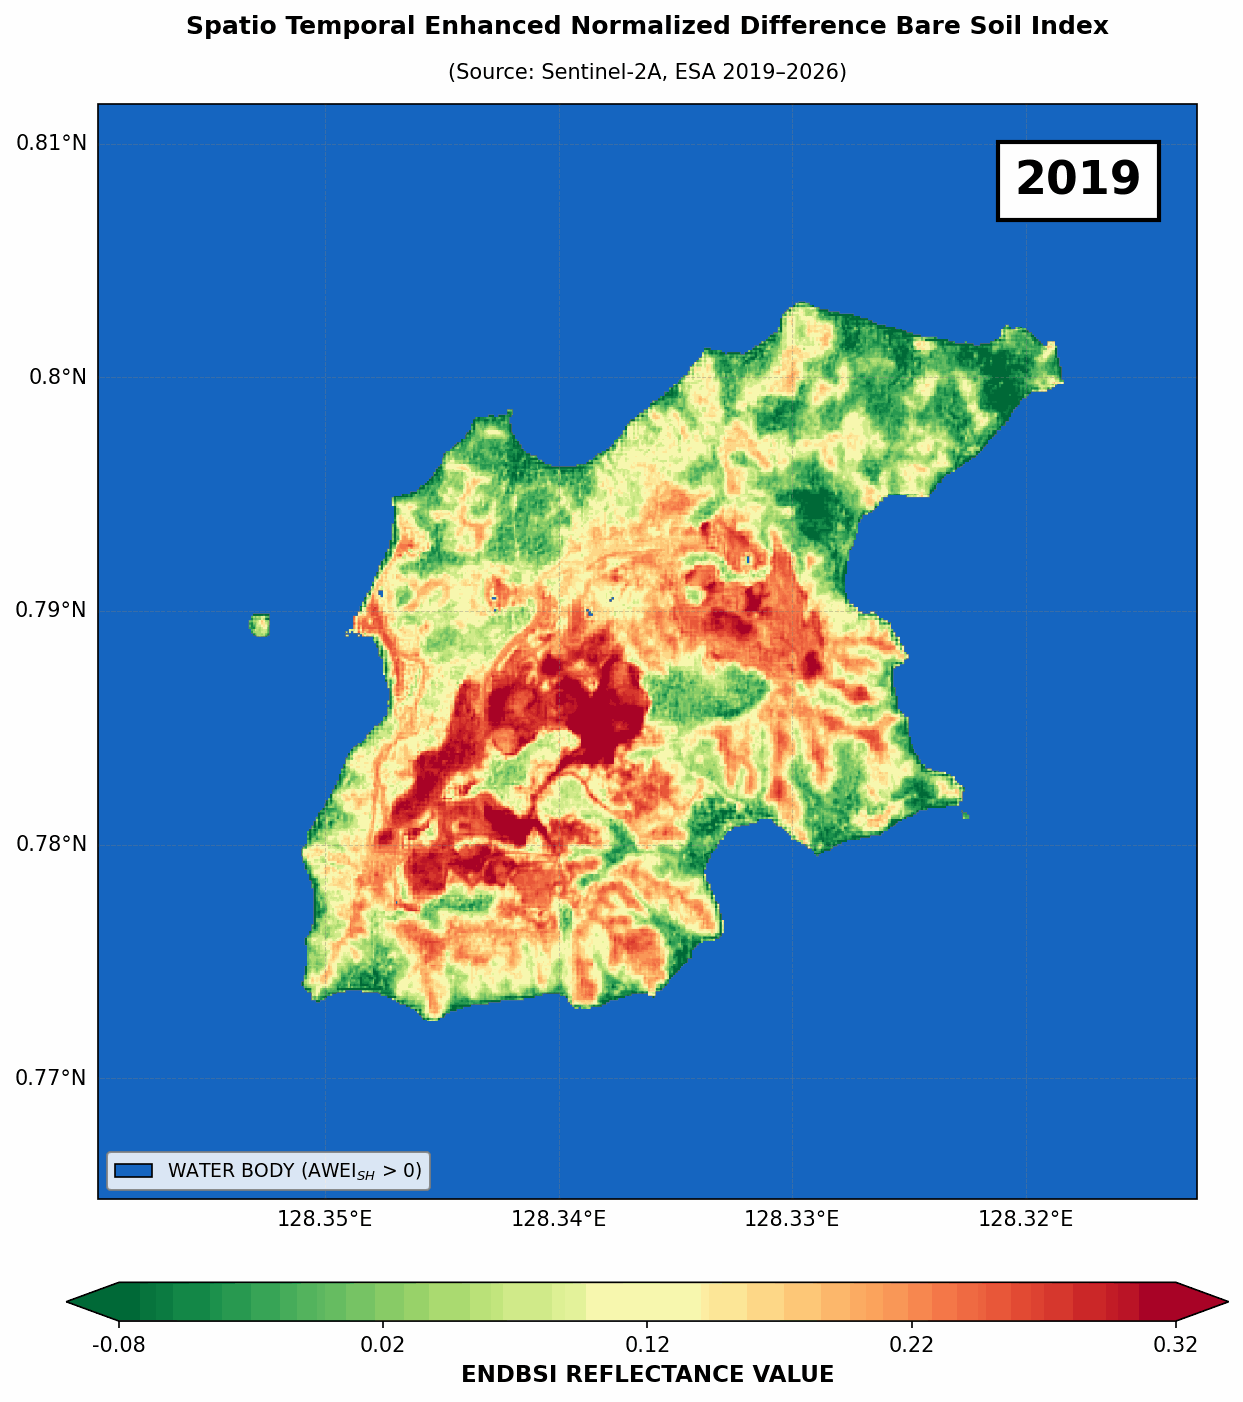

In [45]:
from IPython.display import Image, display

# TAMPILKAN GIF YANG SUDAH DIBUAT
display(Image(filename=output_gif))

In [36]:
from google.colab import files

files.download(output_gif)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **4. Animasi Komposit True Color dan False Color**

Bagian ini akan membuat animasi temporal dari komposit True Color (Warna Asli) dan False Color (Warna Palsu) menggunakan citra satelit Sentinel-2. Animasi ini memberikan perspektif visual yang berbeda terhadap perubahan tutupan lahan di wilayah studi dari tahun 2019 hingga 2026.

### **A. Animasi Komposit True Color (Warna Asli)**

Komposit True Color menampilkan citra satelit mendekati apa yang dilihat mata manusia, dengan band Merah, Hijau, dan Biru (B4, B3, B2) yang dipetakan langsung ke saluran warna Merah, Hijau, dan Biru pada tampilan. Ini sangat berguna untuk identifikasi visual fitur-fitur permukaan bumi seperti vegetasi hijau, air, dan area perkotaan dengan warna aslinya. Tujuan dari animasi ini adalah untuk menunjukkan perubahan visual lahan dari tahun ke tahun secara langsung.

In [62]:
import imageio.v2 as imageio_v2 # Add import here to ensure imageio_v2 is available
import os # Ensure os is imported for path checking

# DEFINISIKAN PARAMETER VISUALISASI UNTUK TRUE COLOR (BAND B4, B3, B2)
true_color_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0, 'max': 0.3,
    'gamma': 1.3,
    'opacity': 1.0
}

# INISIALISASI DAFTAR UNTUK MENYIMPAN NAMA FILE BINGKAI GAMBAR TRUE COLOR
frames_true_color = []

# LOOPING UNTUK SETIAP TAHUN
for year in python_years:
    # FILTER CITRA BERDASARKAN TAHUN
    img = col.filter(ee.Filter.eq('year', year)).first()

    # INISIALISASI PLOT MATPLOTLIB DENGAN PROYEKSI CARTOPY
    fig = plt.figure(figsize=(10, 12))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # TAMBAHKAN LAYER TRUE COLOR KE PETA
    cartoee.add_layer(ax, img, region=region_bbox, vis_params=true_color_vis)

    # KONFIGURASI GRIDLINES DAN LABEL LINTANG/BUJUR
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # TAMBAHKAN JUDUL PETA
    ax.text(0.5, 1.06, 'TRUE COLOR COMPOSITE', transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='bottom')

    # TAMBAHKAN SUMBER DATA
    ax.text(0.5, 1.02, '(SOURCE: SENTINEL-2A, ESA 2019–2026)', transform=ax.transAxes,
            fontsize=10, fontweight='normal', ha='center', va='bottom')

    # TAMBAHKAN LABEL TAHUN PADA PETA
    ax.text(0.95, 0.95, str(year), transform=ax.transAxes,
            fontsize=22, fontweight='bold', ha='right', va='top',
            bbox=dict(facecolor='white', edgecolor='black', linewidth=2, pad=8))

    # SIMPAN BINGKAI SEBAGAI FILE PNG DAN TUTUP FIGURE
    fname_tc = f'frame_true_color_{year}.png'
    plt.savefig(fname_tc, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    frames_true_color.append(fname_tc)
    print(f'TRUE COLOR FRAME {year} DONE')

# NAMA FILE OUTPUT GIF TRUE COLOR
output_gif_tc = 'True_Color_Temporal_2019_2026.gif'

# BUAT GIF DARI SEMUA BINGKAI TRUE COLOR
with imageio_v2.get_writer(output_gif_tc, mode='I', duration=1.5, loop=0) as writer:
    for fname_tc in frames_true_color:
        writer.append_data(imageio_v2.imread(fname_tc))

# HAPUS FILE GAMBAR PNG SEMENTARA SETELAH GIF SELESAI DIBUAT
# for fname_tc in frames_true_color:
    # os.remove(fname_tc)

print(f'SAVED: {output_gif_tc}')

TRUE COLOR FRAME 2019 DONE
TRUE COLOR FRAME 2020 DONE
TRUE COLOR FRAME 2021 DONE
TRUE COLOR FRAME 2022 DONE
TRUE COLOR FRAME 2023 DONE
TRUE COLOR FRAME 2024 DONE
TRUE COLOR FRAME 2025 DONE
TRUE COLOR FRAME 2026 DONE
SAVED: True_Color_Temporal_2019_2026.gif


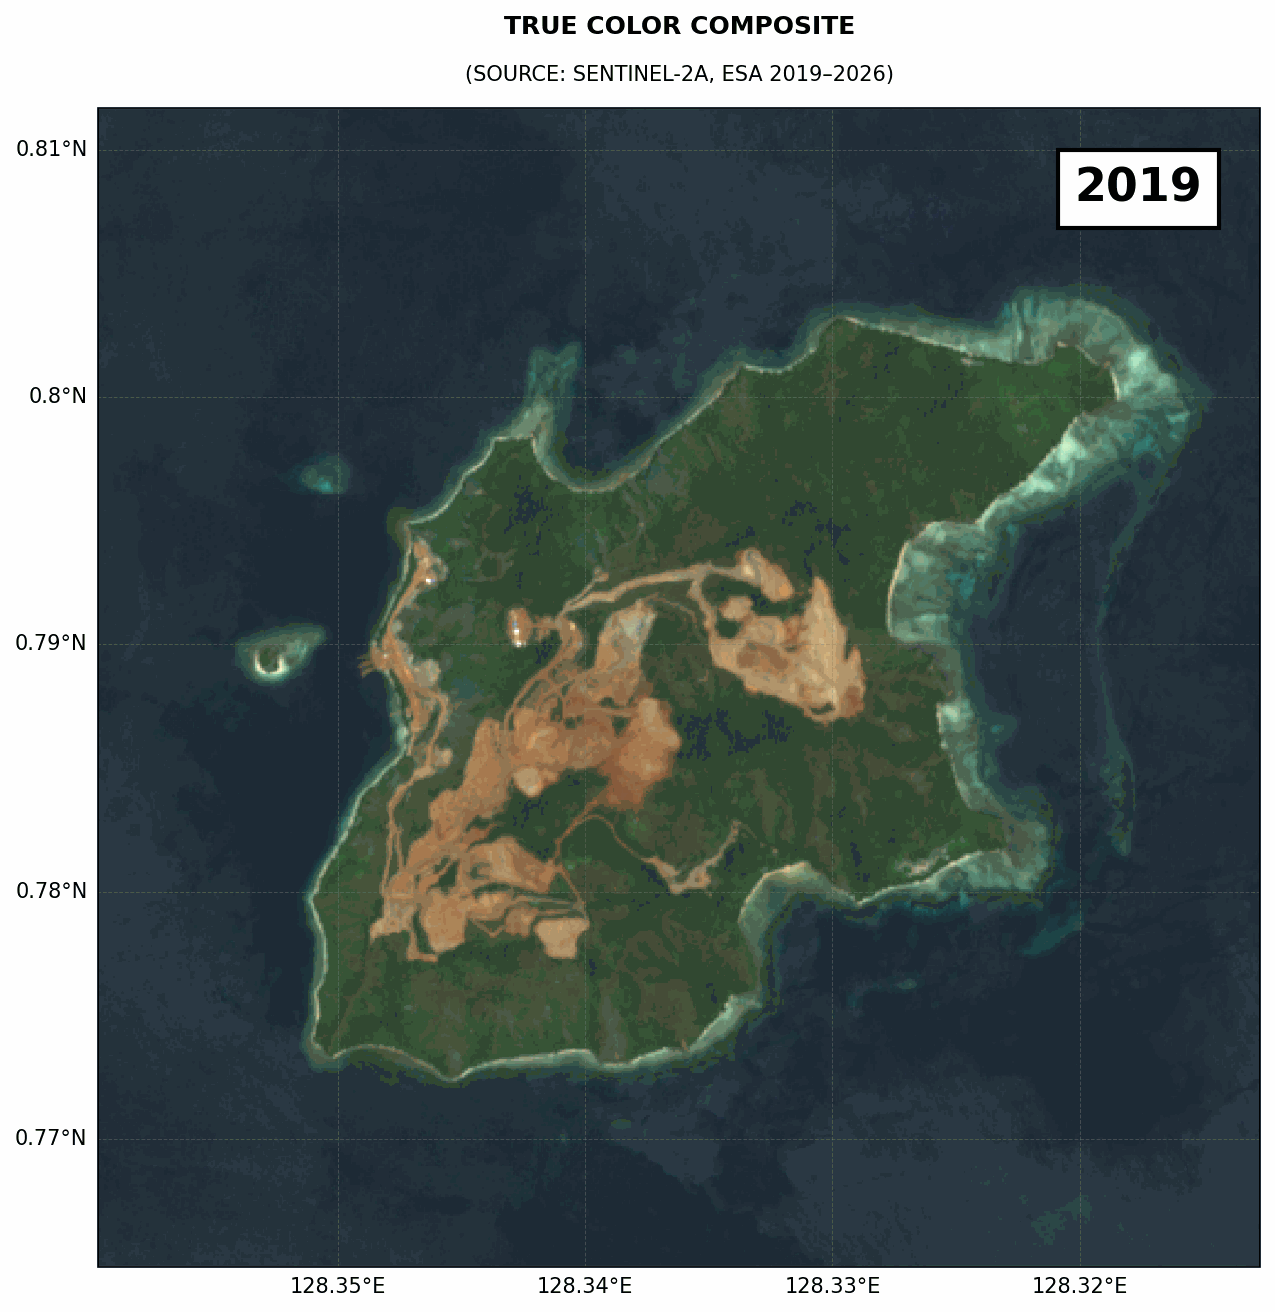

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
from IPython.display import Image, display

# TAMPILKAN GIF TRUE COLOR
display(Image(filename=output_gif_tc))

from google.colab import files

# UNDUH GIF TRUE COLOR
files.download(output_gif_tc)

### **B. Animasi Komposit False Color (Warna Palsu)**

Komposit False Color mengalokasikan band spektral ke saluran warna Merah, Hijau, dan Biru dengan cara yang berbeda dari True Color, seringkali untuk menonjolkan fitur tertentu yang tidak terlihat jelas oleh mata manusia. Untuk Sentinel-2, komposit False Color yang umum digunakan adalah dengan memetakan band NIR (B8), Merah (B4), dan Hijau (B3) ke saluran RGB. Ini sangat efektif untuk membedakan jenis vegetasi, kesehatan tanaman, dan batas antara daratan dan air.

Tujuan dari animasi ini adalah untuk memberikan visualisasi yang lebih baik terhadap perubahan vegetasi dan batas air/daratan selama periode 2019–2026.

In [61]:
import imageio.v2 as imageio_v2 # Add import here to ensure imageio_v2 is available
import os # Ensure os is imported for path checking

# DEFINISIKAN PARAMETER VISUALISASI UNTUK FALSE COLOR (BAND B8, B4, B3)
false_color_vis = {
    'bands': ['B8', 'B4', 'B3'],
    'min': 0.0,
    'max': 0.5,
    'gamma': 1.3,
    'opacity': 1.0
}

# INISIALISASI DAFTAR UNTUK MENYIMPAN NAMA FILE BINGKAI GAMBAR FALSE COLOR
frames_false_color = []

# LOOPING UNTUK SETIAP TAHUN
for year in python_years:
    # FILTER CITRA BERDASARKAN TAHUN
    img = col.filter(ee.Filter.eq('year', year)).first()

    # INISIALISASI PLOT MATPLOTLIB DENGAN PROYEKSI CARTOPY
    fig = plt.figure(figsize=(10, 12))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # TAMBAHKAN LAYER FALSE COLOR KE PETA
    cartoee.add_layer(ax, img, region=region_bbox, vis_params=false_color_vis)

    # KONFIGURASI GRIDLINES DAN LABEL LINTANG/BUJUR
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # TAMBAHKAN JUDUL PETA
    ax.text(0.5, 1.06, 'FALSE COLOR COMPOSITE', transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='bottom')

    # TAMBAHKAN SUMBER DATA
    ax.text(0.5, 1.02, '(SOURCE: SENTINEL-2A, ESA 2019–2026)', transform=ax.transAxes,
            fontsize=10, fontweight='normal', ha='center', va='bottom')

    # TAMBAHKAN LABEL TAHUN PADA PETA
    ax.text(0.95, 0.95, str(year), transform=ax.transAxes,
            fontsize=22, fontweight='bold', ha='right', va='top',
            bbox=dict(facecolor='white', edgecolor='black', linewidth=2, pad=8))

    # SIMPAN BINGKAI SEBAGAI FILE PNG DAN TUTUP FIGURE
    fname_fc = f'frame_false_color_{year}.png'
    plt.savefig(fname_fc, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    frames_false_color.append(fname_fc)
    print(f'FALSE COLOR FRAME {year} DONE')

# NAMA FILE OUTPUT GIF FALSE COLOR
output_gif_fc = 'False_Color_Temporal_2019_2026.gif'

# BUAT GIF DARI SEMUA BINGKAI FALSE COLOR
with imageio_v2.get_writer(output_gif_fc, mode='I', duration=1.5, loop=0) as writer:
    for fname_fc in frames_false_color:
        writer.append_data(imageio_v2.imread(fname_fc))

# HAPUS FILE GAMBAR PNG SEMENTARA SETELAH GIF SELESAI DIBUAT
# for fname_fc in frames_false_color:
    # os.remove(fname_fc)

print(f'SAVED: {output_gif_fc}')

FALSE COLOR FRAME 2019 DONE
FALSE COLOR FRAME 2020 DONE
FALSE COLOR FRAME 2021 DONE
FALSE COLOR FRAME 2022 DONE
FALSE COLOR FRAME 2023 DONE
FALSE COLOR FRAME 2024 DONE
FALSE COLOR FRAME 2025 DONE
FALSE COLOR FRAME 2026 DONE
SAVED: False_Color_Temporal_2019_2026.gif


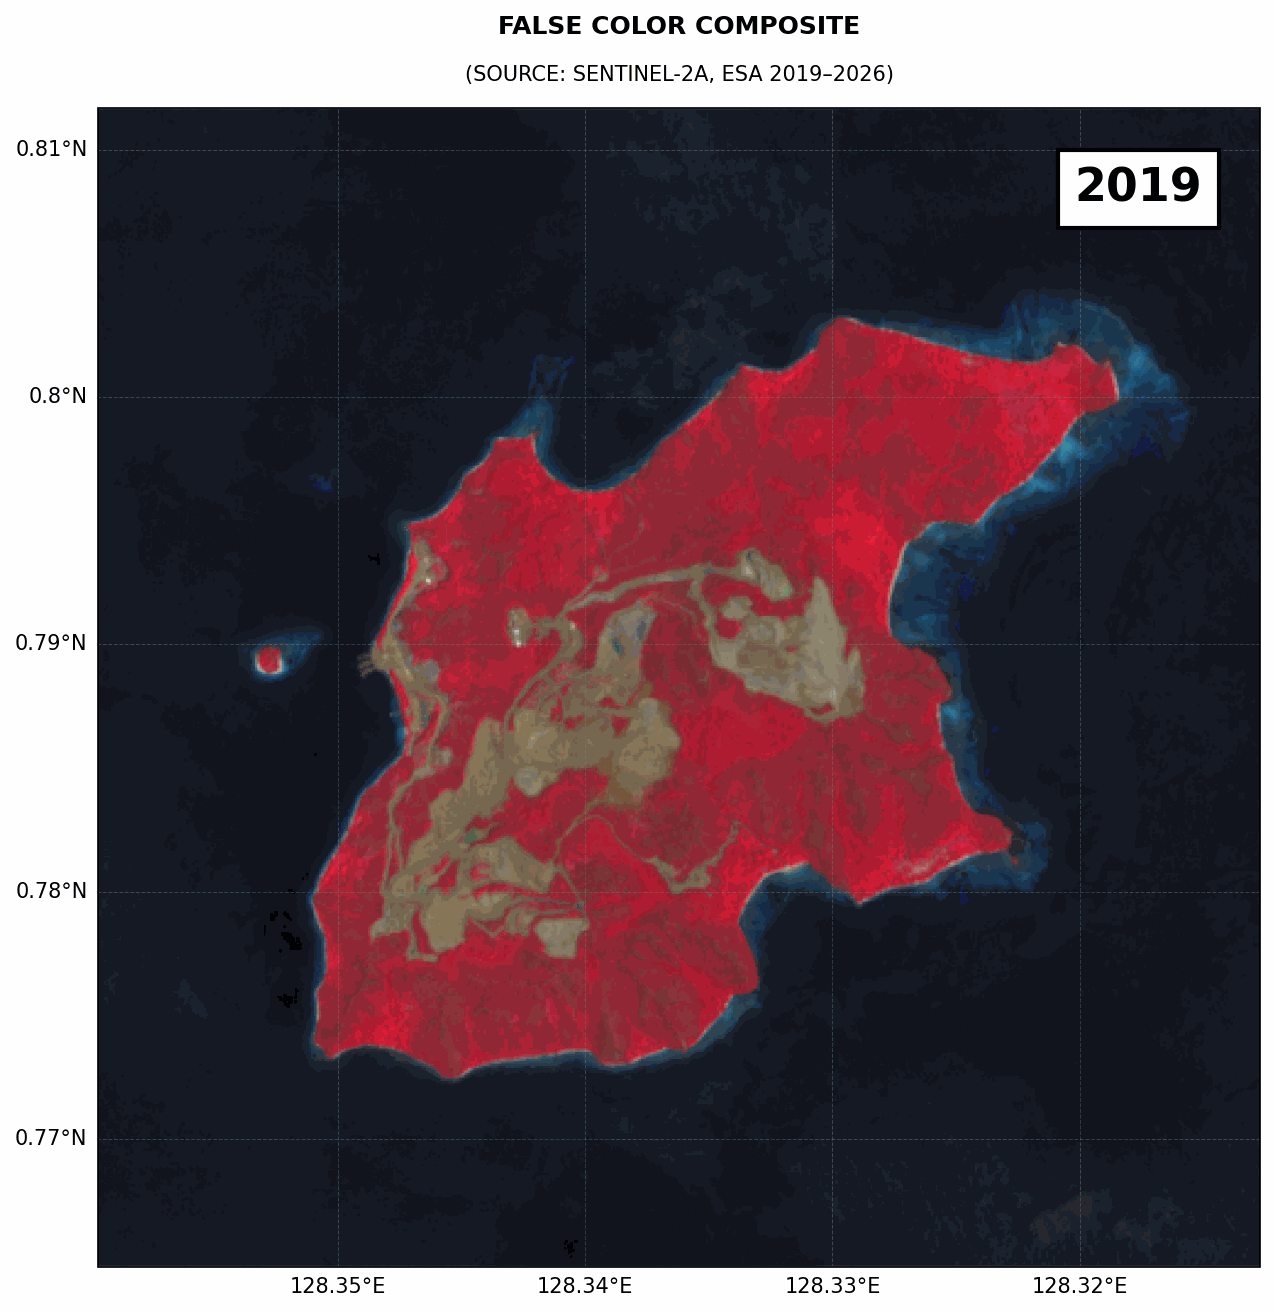

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from IPython.display import Image, display

# TAMPILKAN GIF FALSE COLOR
display(Image(filename=output_gif_fc))

from google.colab import files

# UNDUH GIF FALSE COLOR
files.download(output_gif_fc)

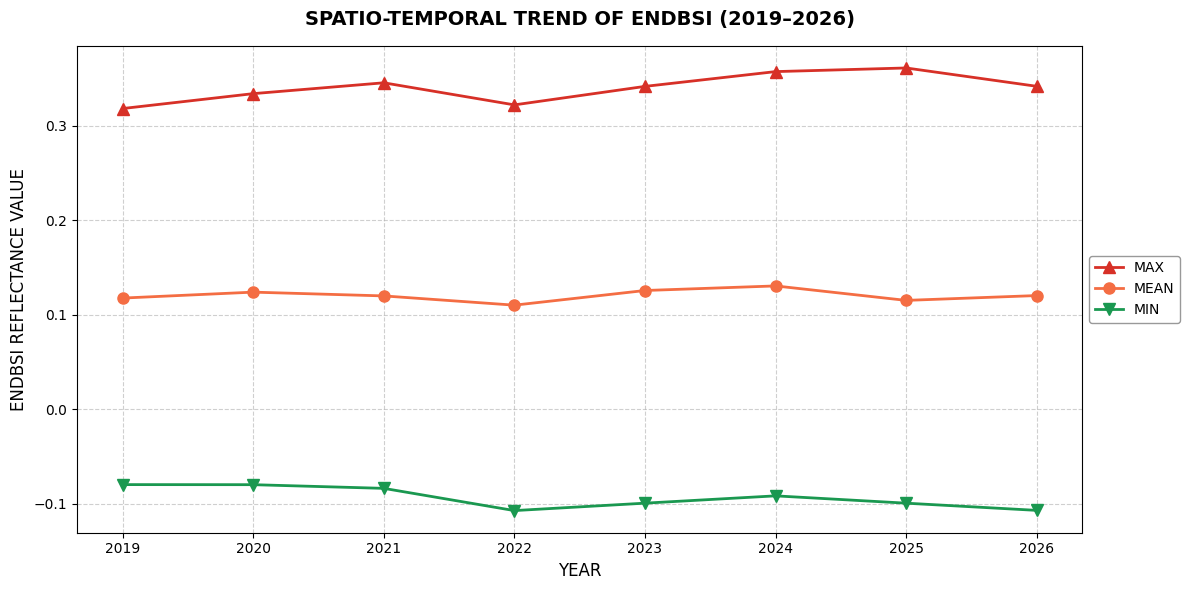

In [47]:
# CALCULATE AND PLOT SPATIO-TEMPORAL TRENDS OF ENDBSI.
import numpy as np

def get_endbsi_stats(img):
    endbsi = img.select('ENDBSI')
    awei_sh = img.select('AWEI_sh')

    land_mask = awei_sh.lte(0)
    endbsi_land = endbsi.updateMask(land_mask)

    reducers = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.percentile([2, 98]),
        sharedInputs=True
    )

    stats = endbsi_land.reduceRegion(
        reducer=reducers,
        geometry=roi,
        scale=10,
        maxPixels=1e9
    )
    return img.set(stats)

stats_fc = col.map(get_endbsi_stats)
stats_data = stats_fc.getInfo()['features']

plot_years = [f['properties']['year'] for f in stats_data]
plot_mean = [f['properties'].get('ENDBSI_mean') for f in stats_data]
plot_min = [f['properties'].get('ENDBSI_p2') for f in stats_data]
plot_max = [f['properties'].get('ENDBSI_p98') for f in stats_data]

fig_chart, ax_chart = plt.subplots(figsize=(12, 6))

# LINE CHART PLOTTING
ax_chart.plot(plot_years, plot_max, color='#d73027', marker='^', linewidth=2, markersize=8, label='MAX')
ax_chart.plot(plot_years, plot_mean, color='#f46d43', marker='o', linewidth=2, markersize=8, label='MEAN')
ax_chart.plot(plot_years, plot_min, color='#1a9850', marker='v', linewidth=2, markersize=8, label='MIN')

ax_chart.set_title('SPATIO-TEMPORAL TREND OF ENDBSI (2019–2026)', fontsize=14, fontweight='bold', pad=15)
ax_chart.set_xlabel('YEAR', fontsize=12)
ax_chart.set_ylabel('ENDBSI REFLECTANCE VALUE', fontsize=12)
ax_chart.set_xticks(plot_years)
ax_chart.grid(True, linestyle='--', alpha=0.6)
ax_chart.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, edgecolor='gray')

plt.tight_layout()
chart_filename = "Chart_Trend_ENDBSI.png"
plt.savefig(chart_filename, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## **Daftar Pustaka**

* Chen, J., Zhong, Y., Tang, B.-H., Huang, L., Fu, Z., Fan, D., Zhao, T., & Yang, C. (2026). ENDBSI: an Enhanced Normalized Difference Bare Soil Index for identifying the bare soil of urban and rural regions in China. *GIScience & Remote Sensing*, 63(1), 2626630. https://doi.org/10.1080/15481603.2026.2626630
* Feyisa, G. L., Meilby, H., Fensholt, R., & Proud, S. R. (2014). Automated Water Extraction Index: A new technique for surface water mapping using Landsat imagery. *Remote Sensing of Environment*, 140, 23–35. https://doi.org/10.1016/j.rse.2013.08.029
* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
* Markert, K. N. (2019). cartoee: Publication quality maps using Earth Engine. *Journal of Open Source Software*, 4(33), 1207. https://doi.org/10.21105/joss.01207
* Met Office. (2013). Cartopy: A cartographic Python library with matplotlib support. Exeter, Devon. http://scitools.org.uk/cartopy
* Wu, Q. (2020). geemap: A Python package for interactive mapping with Google Earth Engine. *Journal of Open Source Software*, 5(51), 2305. https://doi.org/10.21105/joss.02305

## **Dokumentasi Pustaka (Package Documentation)**

* **`geemap`**: https://geemap.org/
* **`cartopy`**: https://cartopy.readthedocs.io/stable/
* **`matplotlib`**: https://matplotlib.org/
* **`cartoee`**: https://cartoee.readthedocs.io/en/latest/